<a href="https://colab.research.google.com/github/gracella12/PCD_Assignment/blob/main/PCDAssignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 3: Segmentation & Morphology
Nama: Gracella Wiendy Koesnadi

NIM: 24/541739/PA/22991

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageFilter, ImageEnhance

#Segmentation

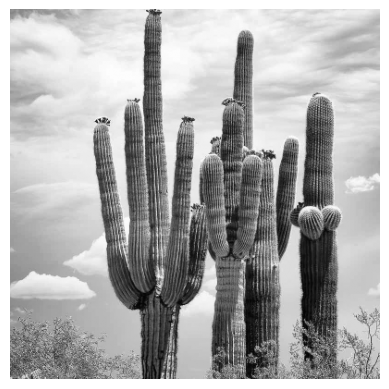

In [ ]:
ori_path = "/content/kaktus.jpg"
image1 = cv2.imread(ori_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(image1, cmap='gray')
plt.axis('off')
plt.show()

Text(0.5, 1.0, 'Histogram Asli')

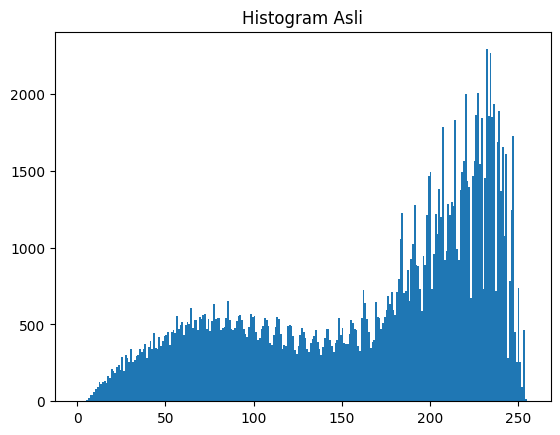

In [ ]:
plt.hist(image1.ravel(), bins=256, range=[0,256])
plt.title("Histogram Asli")

##Basic Thresholding
Basic Thresholding bekerja dengan mengklasifikasikan pixel menjadi foreground dan background dengan batas threshold

Objek yang digunakan memiliki foreground yang lebih gelap dibandingkan backgroundnya sehingga pengklasifikasian terjadi dengan aturan sebagai berikut:

1.   Jika I(x,y) <= threshold, ubah pixel menjadi 255
2.   Jika I(x,y) > threshold, ubah pixel menjadi 0

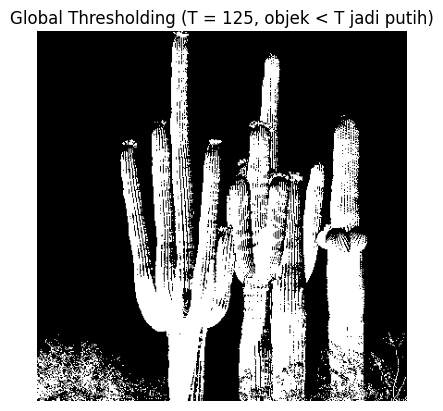

In [ ]:
height, width = image1.shape

T = 125
thresholded = Image.new("L", (width, height))
pix_out = thresholded.load()

# --- Proses Global Thresholding (kebalikan dari sebelumnya) ---
for y in range(height):
    for x in range(width):
        # Jika intensitas < T → 1 (putih)
        # Jika intensitas >= T → 0 (hitam)
        pix_out[x, y] = 255 if image1[y, x] < T else 0

# --- Tampilkan hasil ---
plt.imshow(thresholded, cmap='gray')
plt.axis('off')
plt.show()

Diskusi: Threshold yang digunakan adalah 125 dikarenakan diambil dari nilai tengah antara 100 dan 150. Hal tersebut dikarenakan sebaran intensitas yang rendah berada pada rentang 100 dan 150. Dapat dilihat bahwa foregroundnya menjadi putih sehingga objek yang ingin dianalisis menjadi terlihat dengan jelas (terpisah dari background)

##Adaptive Thresholding with Otsu Method
Otsu Method akan mencoba seluruh threshold dan memilih threshold paling optimal.



🔹 Nilai threshold optimal (Otsu): 146


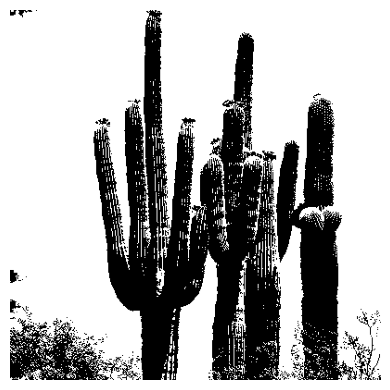

In [ ]:
# Recalculate height and width to ensure correct dimensions
height, width = image1.shape

hist = [0] * 256
# Iterate over the pixel values of image1
for row in image1:
    for p in row:
        hist[p] += 1

# === TOTAL PIXEL ===
total = width * height

# === HITUNG MEAN GLOBAL ===
sum_total = sum(i * hist[i] for i in range(256))

sumB = 0
wB = 0
max_var = 0
threshold = 0

# Otsu Algorithm
for t in range(256):
    wB += hist[t]
    if wB == 0:
        continue
    wF = total - wB
    if wF == 0:
        break

    sumB += t * hist[t]

    mB = sumB / wB
    mF = (sum_total - sumB) / wF

    var_between = wB * wF * (mB - mF) ** 2

    if var_between > max_var:
        max_var = var_between
        threshold = t

print(f"🔹 Nilai threshold optimal (Otsu): {threshold}")

# Hasil
result_img = Image.new("L", (width, height))
pix_res = result_img.load()

for y in range(height):
    for x in range(width):
        pix_res[x, y] = 255 if image1[y][x] >= threshold else 0

# Visualisasi
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(result_img, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

Diskusi: Berdasarkan hasil dari otsu method, thresholding yang paling maksimal adalah 146. Dapat dilihat bahwa objeknya terlihat dengan jelas

#Morphology

##Erosion
Erosion digunakan untuk region separation. Sangat berguna ketika objek menempel satu sama lain sehingga dapat terlihat batasnya. Erotion berfungsi untuk shrinking region

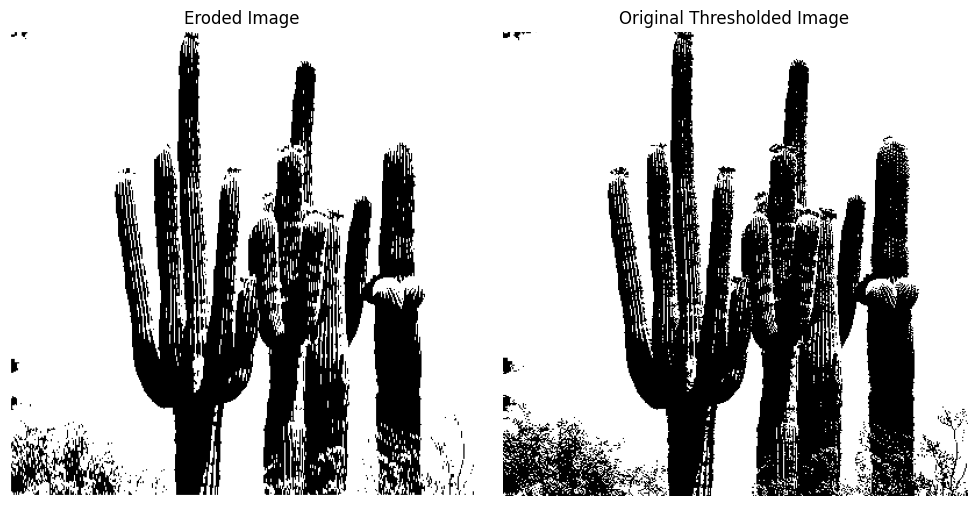

In [ ]:
#using Erosion
width, height = result_img.size

# Kernel Vertical
kernel = [
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
]

k_size = len(kernel)
k_center = k_size // 2

# Siapkan array hasil erosi
eroded = [[255 for _ in range(width)] for _ in range(height)]

# Erotion
for i in range(k_center, height - k_center):
    for j in range(k_center, width - k_center):
        all_black = True
        for m in range(k_size):
            for n in range(k_size):
                if kernel[m][n] == 1:
                    if result_img.load()[j + n - k_center, i + m - k_center]
                        all_black = False
                        break
            if not all_black:
                break

        eroded[i][j] = 0 if all_black else 255

eroded_img_pil = Image.new("L", (width, height))
for i in range(height):
    for j in range(width):
        eroded_img_pil.putpixel((j, i), eroded[i][j])

# Display the eroded image and the original thresholded image side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(eroded_img_pil, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_img, cmap='gray')
plt.title('Original Thresholded Image')
plt.axis('off')

plt.tight_layout()
plt.show()

Diskusi: Dapat dilihat perbandingan kedua gambar tersebut bahwa pada gambar hasil erosi, objek mengalami shrinking region. Hal tersebut telihat dari boundaries putih lebih terlihat dan terlihat lebih terpisah. Kernel yang digunakan adalah vertikal dikarenakan pada gambar tersebut, kaktus-kaktus lebih banyak bentuk vertikalnya.

##Dilation
Dilation digunakan untuk memperbesar luas area region. Biasanya dilation digunakan untuk mengsisi bagian-bagian yang masih kosong. Dilation bekerja dengan menggunakan kernel dimana ketika ada 1 saja yang sama dengan kernel, maka nilai dari pixel tersebut akan menjadi 0 (hal ini disebabkan karena objeknya berwarna hitam)

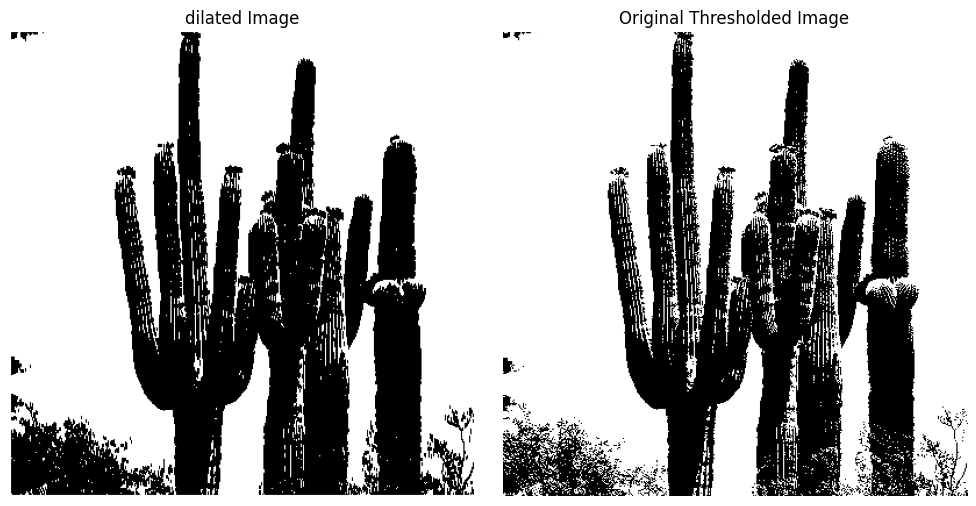

In [ ]:
width, height = result_img.size
pixels = result_img.load()

# Kernel 3x3 Vertical
kernel = [
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
]
k_size = len(kernel)
k_center = k_size // 2

dilated_img = [[255 for _ in range(width)] for _ in range(height)]

# Dilation
for i in range(k_center, height - k_center):
    for j in range(k_center, width - k_center):
        found_black = False
        for m in range(k_size):
            for n in range(k_size):
                if kernel[m][n] == 1:
                    if pixels[j + n - k_center, i + m - k_center] == 0:
                        found_black = True
                        break
            if found_black:
                break

        dilated_img[i][j] = 0 if found_black else

result_dilation = Image.new("L", (width, height))
pix_out = result_dilation.load()

for i in range(height):
    for j in range(width):
        pix_out[j, i] = dilated_img[i][j]

# Visualitation
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(result_dilation, cmap='gray')
plt.title('dilated Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_img, cmap='gray')
plt.title('Original Thresholded Image')
plt.axis('off')

plt.tight_layout()
plt.show()

Diskusi: Berdasarkan gambar diatas, dapat dilihat bahwa gambar yang sudah didilatasi terlihat lebih terisi dibandingkan gambar aslinya

##Opening
Tujuan dari opening hampir sama dengan erotion. Namun, opening menghasilkan gambar yang lebih halus dikarenakan opening mengombinasikan metode erotion yang dilanjutkan dengan dilation. Opening lebih cocok untuk boundary yang lebih kompleks.

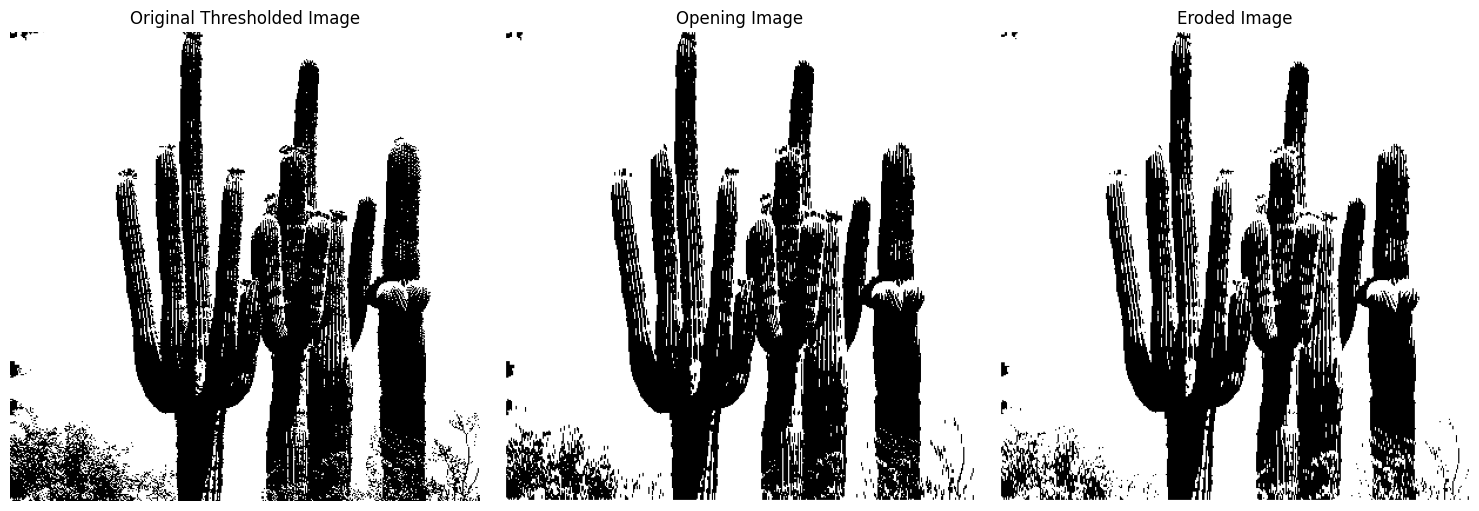

In [106]:
#using Opening (Erosi+Dilation)
width, height = result_img.size
pixels_out = result_img.load()

# Kernel 3x3 untuk erosi (semua 1 berarti kotak penuh)
kernel = [
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
]

k_size = len(kernel)
k_center = k_size // 2  # posisi tengah kernel

# --- Proses Erosi ---
eroded_img= [[255 for _ in range(width)] for _ in range(height)]

# Erotion
for i in range(k_center, height - k_center):
    for j in range(k_center, width - k_center):
        all_black = True
        for m in range(k_size):
            for n in range(k_size):
                if kernel[m][n] == 1:
                    if result_img.load()[j + n - k_center, i + m - k_center] == 255:
                        all_black = False
                        break
            if not all_black:
                break

        eroded_img[i][j] = 0 if all_black else 255

#Dilation
dilated_img = [[255 for _ in range(width)] for _ in range(height)]

for i in range(k_center, height - k_center):
    for j in range(k_center, width - k_center):
        found_black = False
        for m in range(k_size):
            for n in range(k_size):
                if kernel[m][n] == 1:
                    if eroded_img[i + m - k_center][j + n - k_center] == 0:
                        found_black = True
                        break
            if found_black:
                break

        dilated_img[i][j] = 0 if found_black else 255

# Display the opening image
result_opening = Image.new("L", (width, height))
pixels_out = result_opening.load()

for i in range(height):
    for j in range(width):
        pixels_out[j, i] = dilated_img[i][j]

#Hasil erosi
result_eroded = Image.new("L", (width, height))
pixels_eroded = result_eroded.load()
for i in range(height):
    for j in range(width):
        # Menyalin array 2D eroded_img ke objek Image
        pixels_eroded[j, i] = eroded_img[i][j]

#visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 2)
plt.imshow(result_opening, cmap='gray')
plt.title('Opening Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_eroded, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

plt.subplot(1, 3, 1)
plt.imshow(result_img, cmap='gray')
plt.title('Original Thresholded Image')
plt.axis('off')

plt.tight_layout()
plt.show()

##Closing
Closing memiliki kegunaan yang hampir serupa dengan dilation. Closing menghasilkan hasil yang lebih bagus dibandingkan dilation, terutama pada boundary yang lebih kompleks. Hal tersebut dikarenakan closing mengombinasikan metode dilation yang dilanjutkan dengan erotion.

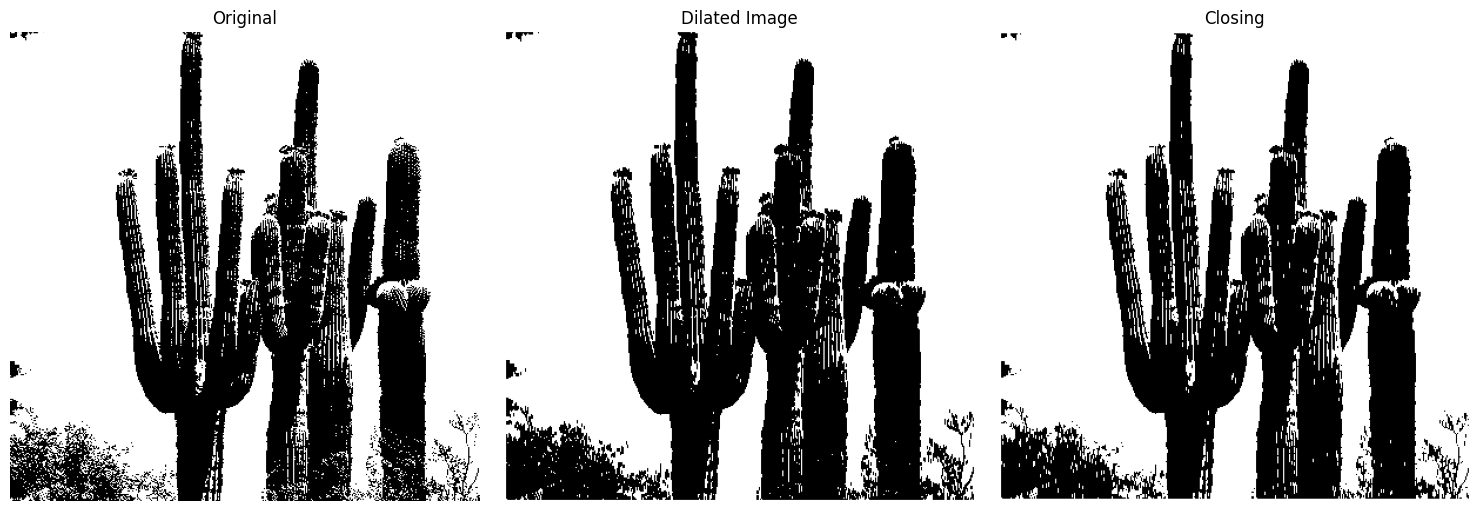

In [108]:
width, height = result_img.size
pixels_input = result_img.load()

# Kernel 3x3 Vertikal
kernel = [
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
]

k_size = len(kernel)
k_center = k_size // 2

#Dilation Process
dilated_img_1 = [[255 for _ in range(width)] for _ in range(height)]

for i in range(k_center, height - k_center):
    for j in range(k_center, width - k_center):
        found_black = False
        for m in range(k_size):
            for n in range(k_size):
                if kernel[m][n] == 1:
                    # KOREKSI 1: Akses piksel input (PIL) menggunakan [kolom, baris]
                    if pixels_input[j + n - k_center, i + m - k_center] == 0:
                        found_black = True
                        break
            if found_black:
                break

        dilated_img_1[i][j] = 0 if found_black else 255

#Erotion Process
eroded_img_1 = [[255 for _ in range(width)] for _ in range(height)]

for i in range(k_center, height - k_center):
    for j in range(k_center, width - k_center):
        all_black = True
        for m in range(k_size):
            for n in range(k_size):
                if kernel[m][n] == 1:
                    # KOREKSI 2: Akses hasil Dilasi (array Python) menggunakan [baris][kolom]
                    if dilated_img_1[i + m - k_center][j + n - k_center] == 255:
                        all_black = False # Found white, so not 'all_black'
                        break
            if not all_black:
                break

        eroded_img_1[i][j] = 0 if all_black else 255


#Closing Result
result_closing = Image.new("L", (width, height))
pixels_closing = result_closing.load()

for i in range(height):
    for j in range(width):
        pixels_closing[j, i] = eroded_img_1[i][j] # Menggunakan hasil Erosi terakhir

# Dilation result
result_dilated = Image.new("L", (width, height))
pixels_dilated_out = result_dilated.load()
for i in range(height):
    for j in range(width):
        pixels_dilated_out[j, i] = dilated_img_1[i][j]


#Visualitation
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(result_img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(result_dilated, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.tight_layout()
plt.show()